In [1]:
!pip install toolapi
!pip install pynufft
!wget -q --show-progress https://github.com/mrx-org/toolapi-py/releases/download/v0.1.0/gre.seq

gre.seq.1           100%[===================>]  86.75K  --.-KB/s    in 0.01s   


In [2]:
# @title Convert NIfTI phantom to toolapi
from pathlib import Path
import json
import re
import tempfile
import nibabel as nib
from nibabel.filebasedimages import ImageFileError
from toolapi.value import Volume, PhantomTissue, SegmentedPhantom

def load_phantom_from_nifti(config_path: str | Path) -> SegmentedPhantom:
    """
    Load a NIfTI phantom from a JSON config + NIfTI files on disk and
    convert it into a toolapi SegmentedPhantom.

    Assumes NIfTI files are already at the desired resolution and affine —
    no resampling is performed.

    Parameters
    ----------
    config_path : path to the phantom JSON config file (e.g. phantom.json)
    """
    config_path = Path(config_path)
    base_dir = config_path.parent

    with open(config_path) as f:
        cfg = json.load(f)

    cache: dict[str, tuple[np.ndarray, np.ndarray]] = {}

    def parse_ref(s: str) -> tuple[str, int]:
        m = re.match(r"^(.+)\[(\d+)\]$", s)
        if not m:
            raise ValueError(f"Invalid ref: {s}")
        return m.group(1), int(m.group(2))

    def load4d(fn: str) -> tuple[np.ndarray, np.ndarray]:
        if fn in cache:
            return cache[fn]
        path = base_dir / fn
        try:
            img = nib.load(str(path))
        except ImageFileError as e:
            if "not a gzip file" in str(e).lower() and str(fn).lower().endswith(".nii.gz"):
                with open(path, "rb") as src, tempfile.NamedTemporaryFile(
                    suffix=".nii", delete=False
                ) as tmp:
                    tmp.write(src.read())
                    tmp_path = tmp.name
                img = nib.load(tmp_path)
            else:
                raise
        dat = img.get_fdata()
        if dat.ndim == 3:
            dat = dat[..., np.newaxis]
        elif dat.ndim != 4:
            raise ValueError(f"Expected 3D or 4D NIfTI, got {dat.ndim}D")
        cache[fn] = (np.asarray(img.affine, dtype=np.float64), dat)
        return cache[fn]

    def make_vol(arr: np.ndarray, aff: np.ndarray) -> Volume:
        return Volume(
            shape=list(arr.shape),
            affine=aff[:3, :4].tolist(),
            data=np.asarray(arr, dtype=np.float64).ravel(order="C").tolist(),
        )

    def _b1_vol_from_array(arr: np.ndarray, aff: np.ndarray) -> Volume:
        v = make_vol(arr, aff)
        v.data = [complex(float(x), 0.0) for x in v.data]
        return v

    tissue_configs = cfg.get("tissues", {})
    tissue_cfg_values = list(tissue_configs.values())
    tissues: dict[str, PhantomTissue] = {}
    first_tissue_config: dict | None = None
    dens_last: np.ndarray | None = None
    aff_last: np.ndarray | None = None

    for _name, t in tissue_configs.items():
        if first_tissue_config is None:
            first_tissue_config = t

        dfn, didx = parse_ref(t["density"])
        aff, d4 = load4d(dfn)
        dens = np.asarray(d4[:, :, :, didx], dtype=np.float64)
        dens_last = dens
        aff_last = aff

        def prop(k: str, default: float) -> float:
            p = t.get(k, default)
            if isinstance(p, (int, float)):
                return float(p)
            if isinstance(p, str):
                fn, idx = parse_ref(p)
                _, v4 = load4d(fn)
                vv = np.asarray(v4[:, :, :, idx], dtype=np.float64).ravel(order="C")
                dd = dens.ravel(order="C")
                s = float(dd.sum())
                return float((dd * vv).sum() / s) if s > 0 else float(default)
            return float(default)

        tissues[_name] = PhantomTissue(
            density=make_vol(dens, aff),
            db0=make_vol(np.ones_like(dens, dtype=np.float64) * prop("dB0", 1.0), aff),
            t1=prop("T1", float("inf")),
            t2=prop("T2", float("inf")),
            t2dash=prop("T2'", float("inf")),
            adc=prop("ADC", 0.0),
        )

    if dens_last is None or aff_last is None:
        raise ValueError("Phantom JSON has no tissues")

    def _first_nonempty_b1(key: str):
        for tt in tissue_cfg_values:
            if not isinstance(tt, dict):
                continue
            vals = tt.get(key, None)
            if isinstance(vals, list) and len(vals) > 0:
                return vals
        return None

    tx_vals = _first_nonempty_b1("B1+")
    rx_vals = _first_nonempty_b1("B1-")
    if tx_vals is None and first_tissue_config:
        tx_vals = first_tissue_config.get("B1+", [1.0])
    if rx_vals is None and first_tissue_config:
        rx_vals = first_tissue_config.get("B1-", [1.0])

    b1_tx: list[Volume] = []
    b1_rx: list[Volume] = []
    for p in tx_vals or [1.0]:
        if isinstance(p, (int, float)):
            arr = np.ones_like(dens_last, dtype=np.float64) * float(p)
            b1_tx.append(_b1_vol_from_array(arr, aff_last))
    for p in rx_vals or [1.0]:
        if isinstance(p, (int, float)):
            arr = np.ones_like(dens_last, dtype=np.float64) * float(p)
            b1_rx.append(_b1_vol_from_array(arr, aff_last))

    if len(b1_tx) == 0:
        b1_tx.append(
            _b1_vol_from_array(np.ones_like(dens_last, dtype=np.float64), aff_last)
        )
    if len(b1_rx) == 0:
        b1_rx.append(
            _b1_vol_from_array(np.ones_like(dens_last, dtype=np.float64), aff_last)
        )

    return SegmentedPhantom(tissues=tissues, b1_tx=b1_tx, b1_rx=b1_rx)

In [3]:
# @title Define tools
import toolapi
from functools import cache

def on_message(msg):
    print(f"\r > {msg}", end="")
    return True

def call(url, **kwargs):
    from time import time
    start = time()
    result = toolapi.call(url, kwargs, on_message)
    print(f"\n --- done ({time() - start:.2f} s) ---")
    return result

# .seq loader: uses disseqt to convert sequence to instant events
def tool_conseq(path, exact_trajectories=True):
    with open(path) as f:
        file_content = f.read()
    return call(
        "wss://tool-conseq.fly.dev/tool",
        seq_file=file_content,
        exact_trajectory=exact_trajectories
    )

# phantom library: returns rescaled brainweb multi-tissue phantoms (slow)
@cache
def tool_phantomlib(subject, res):
    affine = [
        [2.5, 0.0, 0.0, -90.0],
        [0.0, 2.5, 0.0, -108.75],
        [0.0, 0.0, 2.5, -1.25]
    ]
    return call(
        "wss://tool-phantomlib.fly.dev/tool",
        mode="retrieve",
        subject=subject,  # BrainWeb subject
        res_x=res[0],     # X resolution (1-434)
        res_y=res[1],     # Y resolution (1-362)
        res_z=res[2],     # Z resolution (1-434)
        affine=affine,    # orientation and FOV
    )

# not-yet-quite segmented PDG
def tool_sim(sequence, phantom, use_mr0sim=True):
    url = "wss://tool-mr0sim.fly.dev/tool" if use_mr0sim else "wss://tool-rapisim.fly.dev/tool"
    return call(
        url,
        sequence=sequence,
        phantom=phantom,
    )

# trajectory extraction based on pdg sim
def tool_trajex(sequence, phantom):
    return call(
        "wss://tool-trajex.fly.dev/tool",
        sequence=sequence,
        t1=1.0,
        t2=0.1,
        min_mag=1e-3,
    )

 > Returning sequence
 --- done (3.31 s) ---
loading phantom
running simulation
 > Returning signal
 --- done (431.46 s) ---
running trajex
 > Returning trajectory
 --- done (3.18 s) ---


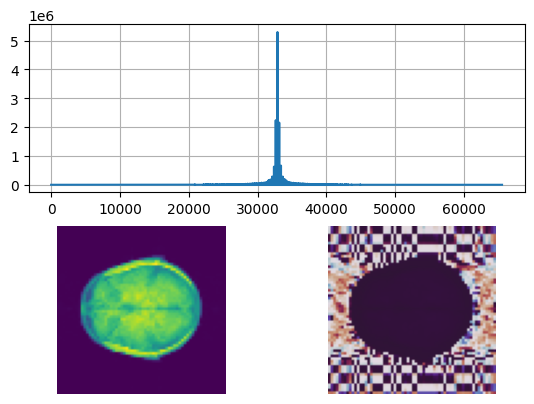

In [5]:
# @title **load .seq + load phantom + run sim** |  _with tools hosted on fly.io_
import numpy as np
from pynufft import NUFFT
import matplotlib.pyplot as plt

local_phantom = "brainweb-subj04/brainweb-subj04-3T.json"
phantomlib = ("brainweb-subj04/brainweb-subj04-3T.json", (72, 87, 1))
seq_file = "gre.seq"

use_mr0sim = False
use_local_phantom = True

seq = tool_conseq(seq_file, exact_trajectories=False)
print("loading phantom")
if use_local_phantom:
    phantom = load_phantom_from_nifti(local_phantom)
else:
    phantom = tool_phantomlib(*phantomlib)
print("running simulation")
signal = np.array(tool_sim(seq, phantom, use_mr0sim))
print("running trajex")
traj = np.array([kt.data for kt in tool_trajex(seq, phantom)]) # This extraction might need some API design work

# Rescale trajectory to [-pi, pi]
traj_norm = traj[:, :2].copy()
traj_norm[:, 0] = traj_norm[:, 0] / np.max(np.abs(traj_norm[:, 0])) * np.pi / 0.22
traj_norm[:, 1] = traj_norm[:, 1] / np.max(np.abs(traj_norm[:, 1])) * np.pi / 0.22
# reconstruct using pynufft
A = NUFFT()
A.plan(
    om=traj_norm, # off-grid locations
    Nd=(64, 64), # size of image
    Kd=(128, 128), # size of oversampled k-space
    Jd=(6, 6) # interpolator kernel size
)
reco = A.adjoint(signal)

# kspace = signal.reshape(256, 256)
# reco = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace)))

plt.figure()
plt.subplot(211)
plt.plot(np.abs(signal))
plt.grid()
plt.subplot(223)
plt.imshow(np.abs(reco), origin="lower", vmin=0)
plt.axis("off")
plt.subplot(224)
plt.imshow(np.angle(reco), origin="lower", vmin=-np.pi, vmax=np.pi, cmap="twilight")
plt.axis("off")
plt.show()
